# NFL Game Prediction — Modeling

This notebook trains and evaluates machine learning models for predicting the probability that the home team wins an NFL game.

The models use pre-game features created in the previous notebook:

- `win_pct_diff`
- `ppg_diff`
- `defense_diff`

The data is split chronologically to prevent future games from influencing predictions about earlier games.

The initial models are:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

The primary evaluation metrics are **Log Loss** and **Brier Score**, since the goal of this project is to produce reliable win probabilities rather than only predicting the winning team.

## 1. Imports

In [103]:
import polars as pl
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

## 2. Load the Feature-Engineered Dataset

The feature engineering notebook saved the processed dataset as a Parquet file.

This dataset contains only information that was available before each game.

In [104]:
model_data = pl.read_parquet(
    "../data/processed/model_data.parquet"
)

print(model_data.shape)

(2895, 86)


In [105]:
model_data.head()

game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,…,home_papg,home_rolling_win_pct_5,home_rolling_ppg_5,home_rolling_papg_5,home_rolling_point_diff_5,away_win_pct,away_ppg,away_papg,away_rolling_win_pct_5,away_rolling_ppg_5,away_rolling_papg_5,away_rolling_point_diff_5,win_pct_diff,ppg_diff,defense_diff,rolling_win_pct_diff_5,rolling_ppg_diff_5,rolling_defense_diff_5,rolling_point_diff_diff_5,home_off_epa,home_def_epa,home_rolling_off_epa_5,home_rolling_def_epa_5,home_rolling_pass_epa_5,home_rolling_rush_epa_5,away_off_epa,away_def_epa,away_rolling_off_epa_5,away_rolling_def_epa_5,away_rolling_pass_epa_5,away_rolling_rush_epa_5,off_epa_diff,def_epa_diff,rolling_off_epa_diff_5,rolling_def_epa_diff_5,rolling_pass_epa_diff_5,rolling_rush_epa_diff_5
str,i32,str,i32,str,str,str,str,i32,str,i32,str,i32,i32,i32,str,i32,str,str,i32,str,i32,i32,i32,i32,i32,f64,i32,i32,f64,i32,i32,i32,str,str,i32,i32,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2015_01_PIT_NE""",2015,"""REG""",1,"""2015-09-10""","""Thursday""","""20:30""","""PIT""",21,"""NE""",28,"""Home""",7,49,0,"""2015091000""",56503,null,"""201509100nwe""",3406,"""400791485""",null,7,7,305,-350,7.5,-111,101,51.0,-107,-103,0,"""outdoors""","""fieldturf""",65,7,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2015_01_IND_BUF""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""IND""",14,"""BUF""",27,"""Home""",13,41,0,"""2015091304""",56504,null,"""201509130buf""",3413,"""400791541""",null,7,7,-109,-101,-1.0,-103,-107,44.5,102,-113,0,"""outdoors""","""a_turf""",56,15,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2015_01_GB_CHI""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""GB""",31,"""CHI""",23,"""Home""",-8,54,0,"""2015091300""",56505,null,"""201509130chi""",3407,"""400791489""",null,7,7,-250,222,-5.5,-110,100,48.5,-107,-103,1,"""outdoors""","""grass""",72,11,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2015_01_KC_HOU""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""KC""",27,"""HOU""",20,"""Home""",-7,47,0,"""2015091306""",56506,null,"""201509130htx""",3409,"""400791493""",null,7,7,-105,-105,-1.0,100,-110,41.0,-103,-107,0,"""closed""","""grass""",null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2015_01_CAR_JAX""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""CAR""",20,"""JAX""",9,"""Home""",-11,29,0,"""2015091302""",56507,null,"""201509130jax""",3411,"""400791547""",null,7,7,-145,131,-3.0,-100,-110,41.0,-107,-103,0,"""outdoors""","""grass""",77,7,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


## 3. Chronological Train / Validation / Test Split

To avoid data leakage, the model is evaluated chronologically.

- Training: 2015–2022
- Validation: 2023
- Test: 2024–2025

The validation set is used to compare models.

The test set is kept separate until the final evaluation.

In [106]:
train_data = model_data.filter(
    pl.col("season") <= 2022
)

validation_data = model_data.filter(
    pl.col("season") == 2023
)

test_data = model_data.filter(
    pl.col("season") >= 2024
)

print("Train:", train_data.shape)
print("Validation:", validation_data.shape)
print("Test:", test_data.shape)

Train: (2079, 86)
Validation: (272, 86)
Test: (544, 86)


## 4. Define Features and Target

The model predicts whether the home team wins.

Features represent the difference between the two teams before the game:

- `win_pct_diff`: difference in previous win percentage
- `ppg_diff`: difference in points scored per game
- `defense_diff`: difference in points allowed per game

The target is:

- `home_win = 1`: home team won
- `home_win = 0`: home team lost

In [107]:
baseline_features = [
    "win_pct_diff",
    "ppg_diff",
    "defense_diff",
]

rolling_features = [
    "rolling_win_pct_diff_5",
    "rolling_ppg_diff_5",
    "rolling_defense_diff_5",
    "rolling_point_diff_diff_5",
]

epa_features = [
    "off_epa_diff",
    "def_epa_diff",
    "rolling_off_epa_diff_5",
    "rolling_def_epa_diff_5",
    "rolling_pass_epa_diff_5",
    "rolling_rush_epa_diff_5",
]

v3_features = (
    baseline_features
    + rolling_features
    + epa_features
)

target = "home_win"

print("Number of V3 features:", len(v3_features))
print(v3_features)

Number of V3 features: 13
['win_pct_diff', 'ppg_diff', 'defense_diff', 'rolling_win_pct_diff_5', 'rolling_ppg_diff_5', 'rolling_defense_diff_5', 'rolling_point_diff_diff_5', 'off_epa_diff', 'def_epa_diff', 'rolling_off_epa_diff_5', 'rolling_def_epa_diff_5', 'rolling_pass_epa_diff_5', 'rolling_rush_epa_diff_5']


In [108]:
print("Features:")
for feature in features:
    print("-", feature)

print("\nNumber of features:", len(features))

Features:
- win_pct_diff
- ppg_diff
- defense_diff
- rolling_win_pct_diff_5
- rolling_ppg_diff_5
- rolling_defense_diff_5
- rolling_point_diff_diff_5

Number of features: 7


In [109]:
train_v3 = train_data.drop_nulls(subset=v3_features)
validation_v3 = validation_data.drop_nulls(subset=v3_features)
test_v3 = test_data.drop_nulls(subset=v3_features)

print("Train V3:", train_v3.shape)
print("Validation V3:", validation_v3.shape)
print("Test V3:", test_v3.shape)

Train V3: (1834, 86)
Validation V3: (256, 86)
Test V3: (512, 86)


## 5. Convert Data for Scikit-Learn

Polars is used for data preparation, while scikit-learn receives NumPy arrays for model training.

In [110]:
X_train = train_v3.select(v3_features).to_numpy()
y_train = train_v3.select(target).to_numpy().ravel()

X_validation = validation_v3.select(v3_features).to_numpy()
y_validation = validation_v3.select(target).to_numpy().ravel()

X_test = test_v3.select(v3_features).to_numpy()
y_test = test_v3.select(target).to_numpy().ravel()

In [111]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1834, 13)
y_train: (1834,)
X_val: (272, 7)
y_val: (272,)
X_test: (512, 13)
y_test: (512,)


## 6. Logistic Regression

Logistic Regression provides a simple baseline model.

It estimates the probability that the home team wins based on the difference between the teams' pre-game statistics.

In [112]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_probs = logistic_model.predict_proba(X_test)[:, 1]
logistic_preds = logistic_model.predict(X_test)

In [113]:
logistic_results = {
    "Model": "Logistic Regression",
    "Log Loss": log_loss(y_test, logistic_probs),
    "Brier Score": brier_score_loss(y_test, logistic_probs),
    "Accuracy": accuracy_score(y_test, logistic_preds),
}

logistic_results

{'Model': 'Logistic Regression',
 'Log Loss': 0.6372248457274572,
 'Brier Score': 0.22285181048095554,
 'Accuracy': 0.64453125}

## 7. Random Forest

Random Forest can capture non-linear relationships between the team statistics.

The model uses multiple decision trees and averages their predictions.

In [114]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = rf_model.predict(X_test)

In [115]:
rf_results = {
    "Model": "Random Forest",
    "Log Loss": log_loss(y_test, rf_probs),
    "Brier Score": brier_score_loss(y_test, rf_probs),
    "Accuracy": accuracy_score(y_test, rf_preds),
}

rf_results

{'Model': 'Random Forest',
 'Log Loss': 0.6349746545000484,
 'Brier Score': 0.22255406562667396,
 'Accuracy': 0.66015625}

## 8. Gradient Boosting

Gradient Boosting builds trees sequentially, with each tree attempting to improve the errors of the previous trees.

In [116]:
gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_probs = gb_model.predict_proba(X_test)[:, 1]
gb_preds = gb_model.predict(X_test)

In [117]:
gb_results = {
    "Model": "Gradient Boosting",
    "Log Loss": log_loss(y_test, gb_probs),
    "Brier Score": brier_score_loss(y_test, gb_probs),
    "Accuracy": accuracy_score(y_test, gb_preds),
}

gb_results

{'Model': 'Gradient Boosting',
 'Log Loss': 0.6707369563652029,
 'Brier Score': 0.23665566885809947,
 'Accuracy': 0.615234375}

## Evaluation

In [118]:
v3_results = pl.DataFrame([
    logistic_results,
    rf_results,
    gb_results,
])

v3_results

Model,Log Loss,Brier Score,Accuracy
str,f64,f64,f64
"""Logistic Regression""",0.637225,0.222852,0.644531
"""Random Forest""",0.634975,0.222554,0.660156
"""Gradient Boosting""",0.670737,0.236656,0.615234


In [119]:
comparison_results = pl.DataFrame([
    {
        "Version": "V1",
        "Model": "Logistic Regression",
        "Log Loss": 0.643111,
        "Brier Score": 0.225625,
        "Accuracy": 0.65625,
    },
    {
        "Version": "V2",
        "Model": "Logistic Regression",
        "Log Loss": 0.639771,
        "Brier Score": 0.224045,
        "Accuracy": 0.65625,
    },
    {
        "Version": "V3",
        "Model": "Logistic Regression",
        "Log Loss": 0.637225,
        "Brier Score": 0.222852,
        "Accuracy": 0.644531,
    },
    {
        "Version": "V1",
        "Model": "Random Forest",
        "Log Loss": 0.639815,
        "Brier Score": 0.224389,
        "Accuracy": 0.642578,
    },
    {
        "Version": "V2",
        "Model": "Random Forest",
        "Log Loss": 0.636091,
        "Brier Score": 0.222829,
        "Accuracy": 0.632812,
    },
    {
        "Version": "V3",
        "Model": "Random Forest",
        "Log Loss": 0.634975,
        "Brier Score": 0.222554,
        "Accuracy": 0.660156,
    },
    {
        "Version": "V1",
        "Model": "Gradient Boosting",
        "Log Loss": 0.672160,
        "Brier Score": 0.237336,
        "Accuracy": 0.591797,
    },
    {
        "Version": "V2",
        "Model": "Gradient Boosting",
        "Log Loss": 0.666090,
        "Brier Score": 0.235537,
        "Accuracy": 0.619141,
    },
    {
        "Version": "V3",
        "Model": "Gradient Boosting",
        "Log Loss": 0.670737,
        "Brier Score": 0.236656,
        "Accuracy": 0.615234,
    },
])

comparison_results

Version,Model,Log Loss,Brier Score,Accuracy
str,str,f64,f64,f64
"""V1""","""Logistic Regression""",0.643111,0.225625,0.65625
"""V2""","""Logistic Regression""",0.639771,0.224045,0.65625
"""V3""","""Logistic Regression""",0.637225,0.222852,0.644531
"""V1""","""Random Forest""",0.639815,0.224389,0.642578
"""V2""","""Random Forest""",0.636091,0.222829,0.632812
"""V3""","""Random Forest""",0.634975,0.222554,0.660156
"""V1""","""Gradient Boosting""",0.67216,0.237336,0.591797
"""V2""","""Gradient Boosting""",0.66609,0.235537,0.619141
"""V3""","""Gradient Boosting""",0.670737,0.236656,0.615234


## Testing

In [120]:
# Use the same games for every feature version
common_test_ids = test_v3.select("game_id").unique()

test_v1_fair = (
    test_data
    .join(common_test_ids, on="game_id", how="inner")
    .drop_nulls(subset=baseline_features)
)

test_v2_fair = (
    test_data
    .join(common_test_ids, on="game_id", how="inner")
    .drop_nulls(subset=rolling_features)
)

test_v3_fair = test_v3

In [126]:
# V1
train_v1_fair = train_data.drop_nulls(subset=baseline_features)
test_v1_fair = test_v1_fair.drop_nulls(subset=baseline_features)

X_train_v1 = train_v1_fair.select(baseline_features).to_numpy()
y_train_v1 = train_v1_fair.select(target).to_numpy().ravel()

X_test_v1 = test_v1_fair.select(baseline_features).to_numpy()
y_test_v1 = test_v1_fair.select(target).to_numpy().ravel()


# V2
train_v2_fair = train_data.drop_nulls(subset=rolling_features)
test_v2_fair = test_v2_fair.drop_nulls(subset=rolling_features)

X_train_v2 = train_v2_fair.select(rolling_features).to_numpy()
y_train_v2 = train_v2_fair.select(target).to_numpy().ravel()

X_test_v2 = test_v2_fair.select(rolling_features).to_numpy()
y_test_v2 = test_v2_fair.select(target).to_numpy().ravel()


# V3
X_train_v3 = train_v3.select(v3_features).to_numpy()
y_train_v3 = train_v3.select(target).to_numpy().ravel()

X_test_v3 = test_v3.select(v3_features).to_numpy()
y_test_v3 = test_v3.select(target).to_numpy().ravel()

In [128]:
print("V1 train:", X_train_v1.shape)
print("V2 train:", X_train_v2.shape)
print("V3 train:", X_train_v3.shape)

print("V1 test:", X_test_v1.shape)
print("V2 test:", X_test_v2.shape)
print("V3 test:", X_test_v3.shape)

V1 train: (1950, 3)
V2 train: (1950, 4)
V3 train: (1834, 13)
V1 test: (512, 3)
V2 test: (512, 4)
V3 test: (512, 13)


In [123]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)

    return {
        "Log Loss": log_loss(y_test, probs),
        "Brier Score": brier_score_loss(y_test, probs),
        "Accuracy": accuracy_score(y_test, preds),
    }

In [124]:
def create_models():
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=10,
            random_state=42
        ),

        "Gradient Boosting": HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42
        )
    }

In [129]:
fair_results = []

versions = {
    "V1": (X_train_v1, y_train_v1, X_test_v1, y_test_v1),
    "V2": (X_train_v2, y_train_v2, X_test_v2, y_test_v2),
    "V3": (X_train_v3, y_train_v3, X_test_v3, y_test_v3),
}

for version, (X_train, y_train, X_test, y_test) in versions.items():

    for model_name, model in create_models().items():

        metrics = evaluate_model(
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )

        fair_results.append({
            "Version": version,
            "Model": model_name,
            **metrics
        })

fair_results_df = pl.DataFrame(fair_results)

fair_results_df

Version,Model,Log Loss,Brier Score,Accuracy
str,str,f64,f64,f64
"""V1""","""Logistic Regression""",0.643111,0.225625,0.65625
"""V1""","""Random Forest""",0.639815,0.224389,0.642578
"""V1""","""Gradient Boosting""",0.67216,0.237336,0.591797
"""V2""","""Logistic Regression""",0.64218,0.225323,0.652344
"""V2""","""Random Forest""",0.640694,0.224931,0.636719
"""V2""","""Gradient Boosting""",0.65732,0.232301,0.628906
"""V3""","""Logistic Regression""",0.637225,0.222852,0.644531
"""V3""","""Random Forest""",0.634975,0.222554,0.660156
"""V3""","""Gradient Boosting""",0.670737,0.236656,0.615234


In [130]:
# Train the final V3 Random Forest again
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

rf_model.fit(X_train_v3, y_train_v3)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [131]:
feature_importance = (
    pl.DataFrame({
        "Feature": v3_features,
        "Importance": rf_model.feature_importances_,
    })
    .sort("Importance", descending=True)
)

feature_importance

Feature,Importance
str,f64
"""win_pct_diff""",0.122472
"""off_epa_diff""",0.121429
"""rolling_off_epa_diff_5""",0.107898
"""rolling_point_diff_diff_5""",0.089846
"""ppg_diff""",0.088976
…,…
"""defense_diff""",0.05465
"""rolling_rush_epa_diff_5""",0.052702
"""rolling_def_epa_diff_5""",0.051201


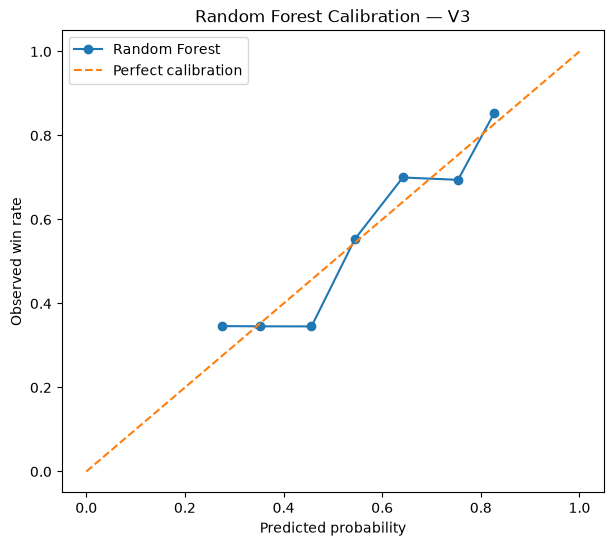

In [132]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Get final V3 RF probabilities
rf_probs = rf_model.predict_proba(X_test_v3)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_test_v3,
    rf_probs,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Predicted probability")
plt.ylabel("Observed win rate")
plt.title("Random Forest Calibration — V3")
plt.legend()
plt.show()

In [134]:
import numpy as np

bins = np.linspace(0, 1, 11)

calibration_data = (
    pl.DataFrame({
        "probability": rf_probs,
        "actual": y_test_v3
    })
    .with_columns(
        pl.col("probability")
        .cut(bins[1:-1].tolist())
        .alias("bin")
    )
)

calibration_data

probability,actual,bin
f64,i8,enum
0.545124,0,"""(0.5, 0.6000000000000001]"""
0.736212,0,"""(0.7000000000000001, 0.8]"""
0.378277,0,"""(0.30000000000000004, 0.4]"""
0.429023,0,"""(0.4, 0.5]"""
0.450957,0,"""(0.4, 0.5]"""
…,…,…
0.43719,1,"""(0.4, 0.5]"""
0.642693,0,"""(0.6000000000000001, 0.7000000…"
0.573435,1,"""(0.5, 0.6000000000000001]"""


In [135]:
calibration_table = (
    pl.DataFrame({
        "probability": rf_probs,
        "actual": y_test_v3
    })
    .with_columns(
        (pl.col("probability") * 10)
        .floor()
        .clip(0, 9)
        .cast(pl.Int64)
        .alias("bin")
    )
    .group_by("bin")
    .agg([
        pl.col("probability").mean().alias("Predicted Probability"),
        pl.col("actual").mean().alias("Observed Win Rate"),
        pl.len().alias("Games")
    ])
    .sort("bin")
    .with_columns(
        (
            pl.col("Predicted Probability") -
            pl.col("Observed Win Rate")
        ).abs().alias("Absolute Error")
    )
)

calibration_table

bin,Predicted Probability,Observed Win Rate,Games,Absolute Error
i64,f64,f64,u32,f64
2,0.274722,0.346154,26,0.071432
3,0.351459,0.345679,81,0.00578
4,0.45668,0.345455,110,0.111225
5,0.544777,0.553571,112,0.008794
6,0.641787,0.7,70,0.058213
7,0.753787,0.694444,72,0.059342
8,0.827228,0.853659,41,0.026431


In [136]:
ece = (
    calibration_table["Absolute Error"] *
    calibration_table["Games"]
).sum() / calibration_table["Games"].sum()

print(f"Expected Calibration Error: {ece:.4f}")

Expected Calibration Error: 0.0488
